In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df=pd.read_csv("/content/weight-height_outliars.csv")

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


<Axes: ylabel='Height'>

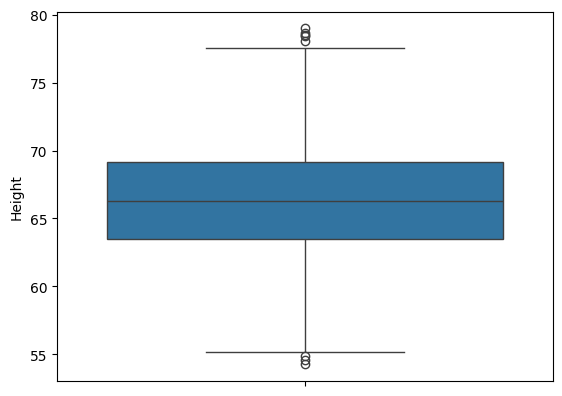

In [6]:
sns.boxplot(df['Height'])

<Axes: ylabel='Weight'>

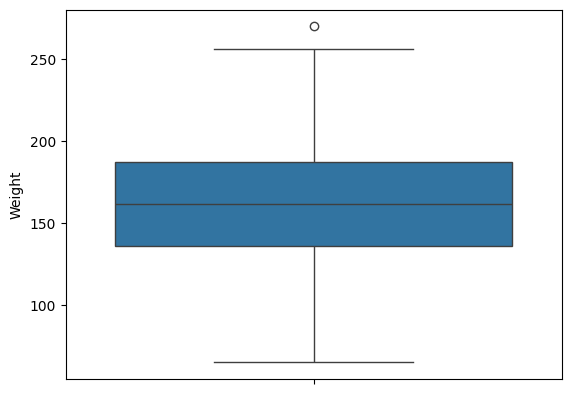

In [8]:
sns.boxplot(df['Weight'])

In [9]:
df.shape

(10000, 3)

In [10]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_1405/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

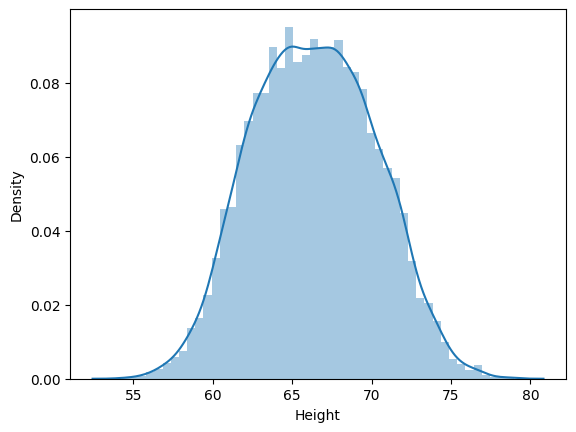

In [11]:
sns.distplot(df['Height'])

In [14]:
max=df['Height'].quantile(0.99)
min=df['Height'].quantile(0.01)
max
min

np.float64(58.13441158671655)

In [15]:
df[(df['Height']>=max) | (df['Height']<=min)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [17]:
new_trimmed=df[(df['Height']<=max) & (df['Height']>=min)]

In [18]:
new_trimmed['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


<Axes: ylabel='Height'>

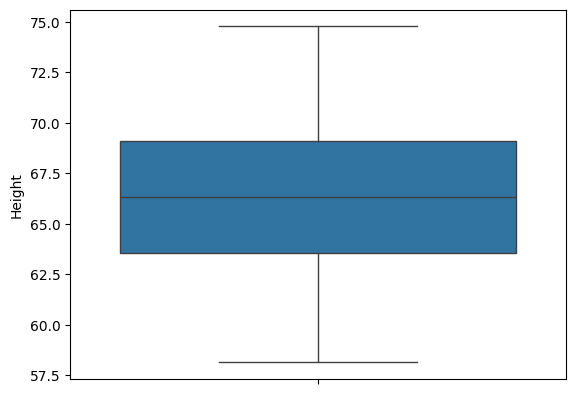

In [19]:
sns.boxplot(new_trimmed['Height'])

#  Capping (Winsorization)

In [22]:
df['Updated_height']=np.where(
    df['Height']>=max,max,
    np.where(
        df['Height']<=min,min,
        df['Height']
    )
)

In [23]:
df['Updated_height'].describe()

,Updated_height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


/tmp/ipykernel_1405/3463660628.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Updated_height'])


<Axes: xlabel='Updated_height', ylabel='Density'>

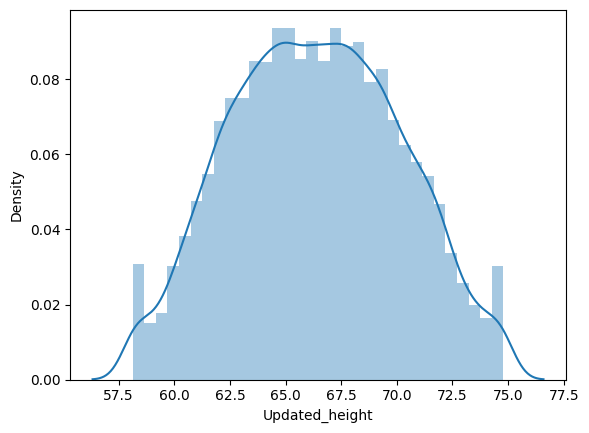

In [24]:
sns.distplot(df['Updated_height'])